In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

DATA_PATH = r"C:\Projects\insurance-underwriting-risk-engine\data\raw\Dataset of health insurance portfolio.xlsx"
DESC_PATH = r"C:\Projects\insurance-underwriting-risk-engine\data\raw\Descriptive of the varaibles.xlsx"

df = pd.read_excel(DATA_PATH)
desc = pd.read_excel(DESC_PATH)

print("Dataset shape:", df.shape)
print("Description shape:", desc.shape)

Dataset shape: (228711, 42)
Description shape: (42, 2)


Understand target/business variables

In [3]:
target_cols = [
    "premium",
    "cost_claims_year",
    "n_medical_services",
    "lapse",
    "age",
    "exposure_time"
]

display(df[target_cols].describe())

,premium,cost_claims_year,n_medical_services,lapse,age,exposure_time
count,228711.000000,228711.000000,228711.000000,228711.000000,228711.000000,228711.000000
mean,852.013382,587.663381,16.812291,2.038232,44.412333,0.935408
std,556.657137,1639.665775,28.228931,0.423944,23.080977,0.232527
min,33.330000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,539.580000,0.000000,0.000000,2.000000,29.000000,1.000000
50%,752.712600,185.640000,6.000000,2.000000,45.000000,1.000000
75%,1024.140000,542.423100,23.000000,2.000000,63.000000,1.000000
max,22318.048800,87000.900000,3094.000000,3.000000,99.000000,1.000000


Check lapse distribution

In [4]:
print(df["lapse"].value_counts())

print(
    df["lapse"].value_counts(normalize=True) * 100
)

lapse
2    187271
3     25092
1     16348
Name: count, dtype: int64
lapse
2    81.881064
3    10.971051
1     7.147885
Name: proportion, dtype: float64


Claims cost distribution

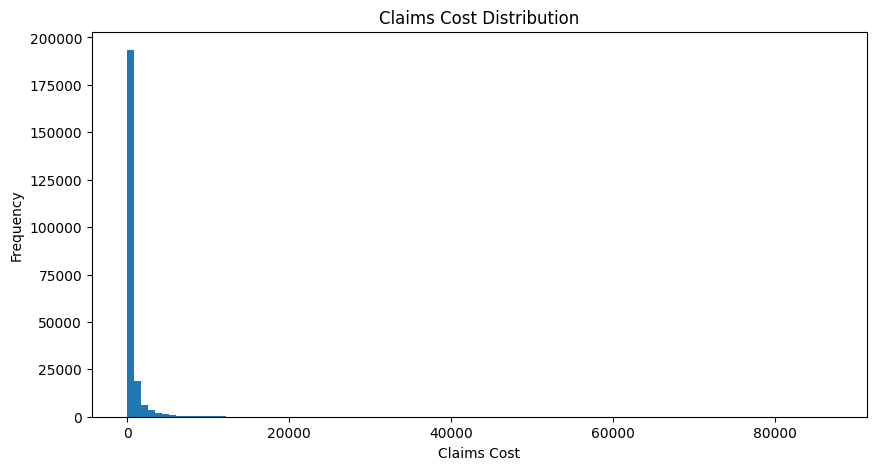

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df["cost_claims_year"],
    bins=100
)

plt.title("Claims Cost Distribution")
plt.xlabel("Claims Cost")
plt.ylabel("Frequency")

plt.show()

Premium distribution

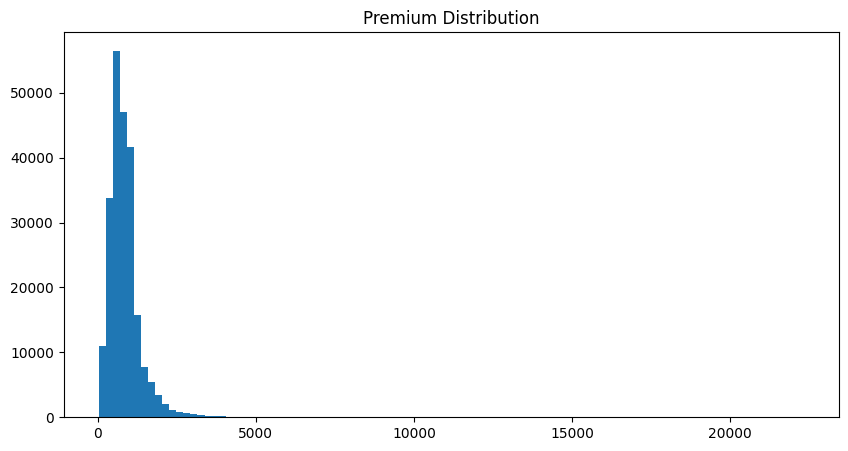

In [6]:
plt.figure(figsize=(10,5))

plt.hist(
    df["premium"],
    bins=100
)

plt.title("Premium Distribution")

plt.show()

Age distribution

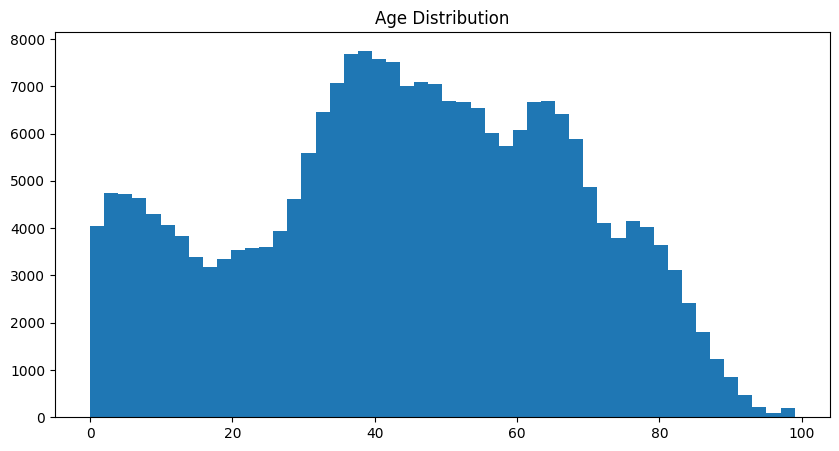

In [7]:
plt.figure(figsize=(10,5))

plt.hist(
    df["age"],
    bins=50
)

plt.title("Age Distribution")

plt.show()

Relationship between premium and claims

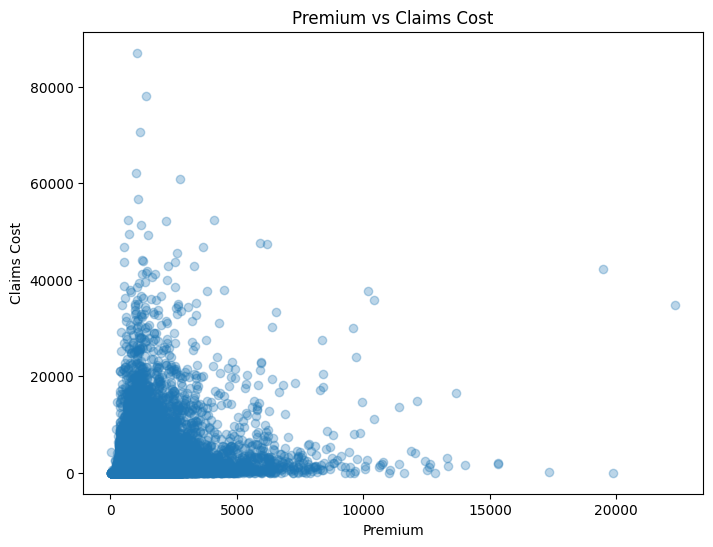

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["premium"],
    df["cost_claims_year"],
    alpha=0.3
)

plt.xlabel("Premium")
plt.ylabel("Claims Cost")
plt.title("Premium vs Claims Cost")

plt.show()

Missing value heatmap

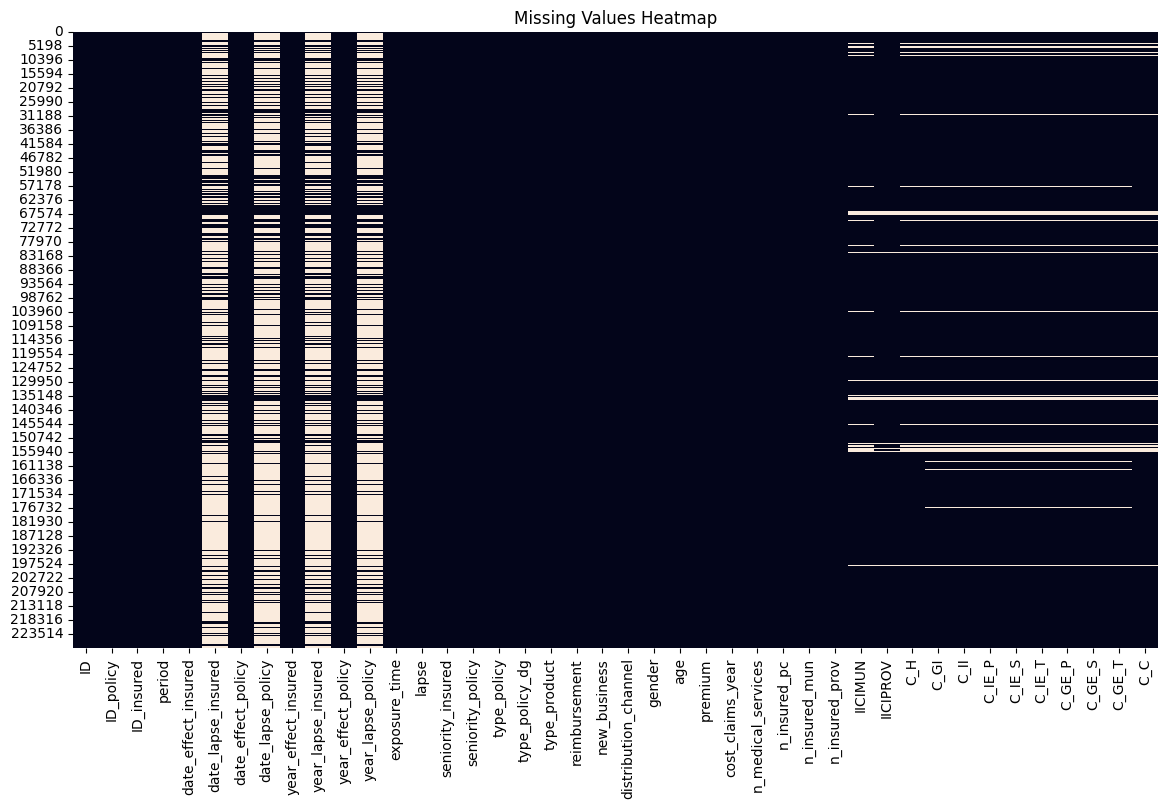

In [9]:
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

Categorical variable distributions

In [10]:
categorical_cols = [
    "gender",
    "type_policy",
    "type_product",
    "distribution_channel",
    "reimbursement"
]

for col in categorical_cols:
    
    print(f"\n{col}")
    
    display(
        df[col].value_counts()
    )


gender


gender
F    123908
M    104803
Name: count, dtype: int64


type_policy


type_policy
I    145471
C     83240
Name: count, dtype: int64


type_product


type_product
S    175415
P     40413
D      9866
I      3017
Name: count, dtype: int64


distribution_channel


distribution_channel
I    144028
A     82644
D      2039
Name: count, dtype: int64


reimbursement


reimbursement
No     186818
Yes     41893
Name: count, dtype: int64

Outlier analysis

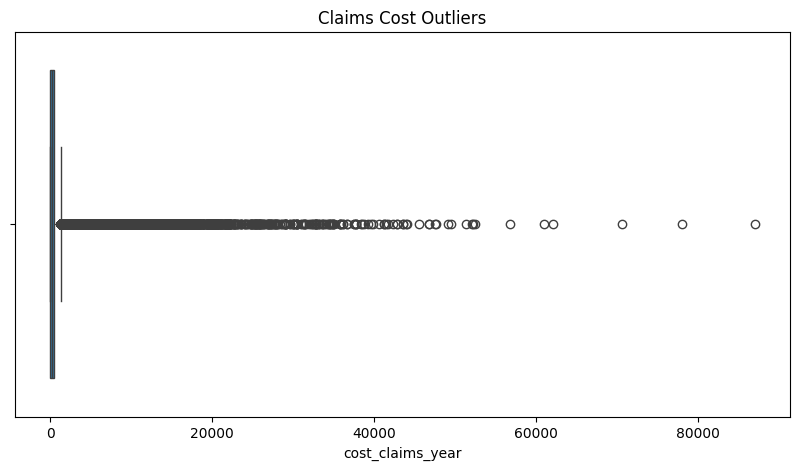

In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["cost_claims_year"]
)

plt.title("Claims Cost Outliers")

plt.show()

Data Cleaning

Create working dataframe

In [12]:
df_clean = df.copy()

print(df_clean.shape)

(228711, 42)


Check duplicate rows

In [13]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


Handle missing values

In [14]:
df_clean["policy_lapsed_flag"] = np.where(
    df_clean["date_lapse_policy"].isnull(),
    0,
    1
)

df_clean["insured_lapsed_flag"] = np.where(
    df_clean["date_lapse_insured"].isnull(),
    0,
    1
)

Fill categorical risk cluster missing values

In [15]:
cluster_cols = [
    "C_H",
    "C_C"
]

df_clean[cluster_cols] = (
    df_clean[cluster_cols]
    .fillna("Unknown")
)

Fill numeric regional indicators

In [16]:
numeric_fill_cols = [
    "IICIMUN",
    "IICIPROV",
    "C_GI",
    "C_II",
    "C_IE_P",
    "C_IE_S",
    "C_IE_T",
    "C_GE_P",
    "C_GE_S",
    "C_GE_T"
]

for col in numeric_fill_cols:
    
    df_clean[col] = (
        df_clean[col]
        .fillna(df_clean[col].median())
    )

Verify missing values again

In [17]:
missing_after = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_after[missing_after > 0]
)

year_lapse_policy     174568
date_lapse_policy     174568
date_lapse_insured    167181
year_lapse_insured    167181
dtype: int64

Check impossible values

In [18]:
print("Age < 0:", (df_clean["age"] < 0).sum())

print("Premium <= 0:",
      (df_clean["premium"] <= 0).sum())

print("Claims < 0:",
      (df_clean["cost_claims_year"] < 0).sum())

Age < 0: 0
Premium <= 0: 0
Claims < 0: 0


Remove zero exposure rows

In [19]:
df_clean = df_clean[
    df_clean["exposure_time"] > 0
]

Final shape check

In [20]:
print(df_clean.shape)

(220066, 44)
